# Start

In [ ]:
from ldst import waves_residual_split, reconstruct_y, normalize_torch

import torch
import torch.nn.functional as F
from torchvision import transforms
import tqdm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = 'cuda'


# Definitions

# Do things

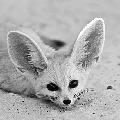

In [ ]:
path_image = 'fenek.png'
oi = Image.open(path_image)
oi


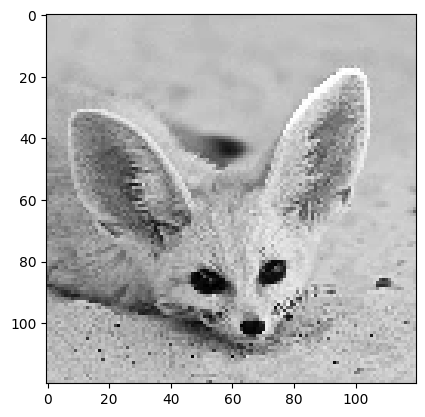

In [ ]:
oi = transforms.ToTensor()(oi).unsqueeze(0).to(device)
plt.imshow(oi[0][0].cpu().numpy(), cmap='gray')

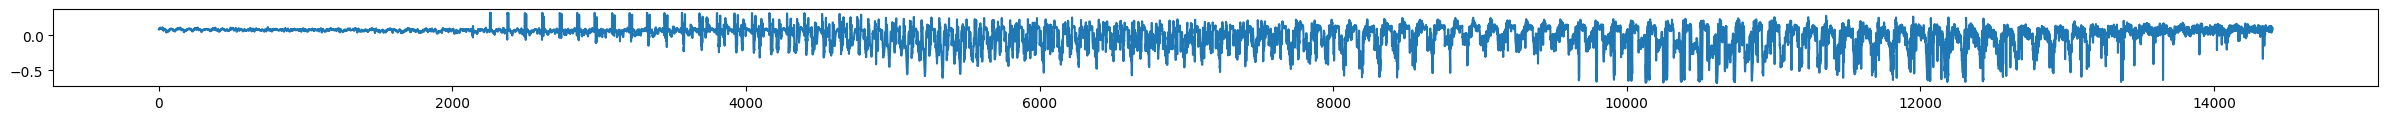

In [ ]:


average_value = oi.mean()
wavelen = oi.shape[2]
oi_flat = oi.flatten() - average_value
n = oi_flat.numel()
x = torch.arange(n).to(device)


plt.figure(figsize=(30, 1))
plt.plot(x.cpu(), oi_flat.cpu())

In [ ]:
num_waves = 13
rolling_window = wavelen // 2
rolling_window = rolling_window if rolling_window % 2 else rolling_window + 1
learning_rate = 0.1

In [ ]:
waves_params, residual = waves_residual_split(x_tensor=x, y_tensor=oi_flat, num_waves=num_waves, rolling_window=rolling_window, learning_rate=learning_rate, device=device, wavelen=wavelen, plot=False)

100%|██████████| 5/5 [00:00<00:00,  9.13it/s]


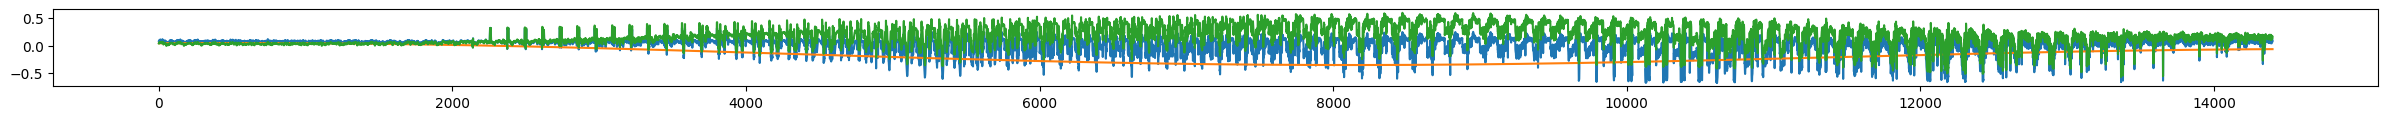

In [ ]:
approximation = reconstruct_y(x, torch.zeros_like(oi_flat), waves_params)
residual = oi_flat - approximation
plt.figure(figsize=(30, 1))
plt.plot(x.cpu(), oi_flat.cpu())
plt.plot(x.cpu(), approximation.detach().cpu().numpy())
plt.plot(x.cpu(), residual.detach().cpu().numpy())
plt.show()

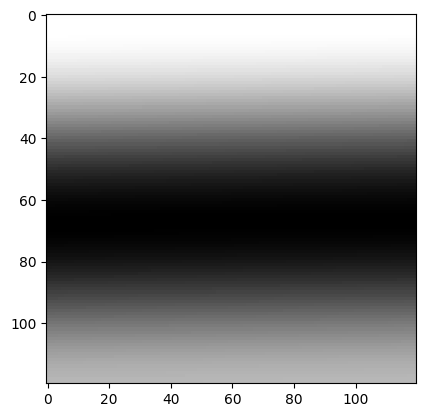

In [ ]:
approx_norm = normalize_torch(approximation.reshape(oi.shape)[0][0])
plt.imshow(approx_norm.cpu(), cmap='gray')

In [ ]:
wavelen = oi.shape[3]
t_oi_flat = oi.squeeze().T.flatten() - average_value
t_waves_params, t_residual = waves_residual_split(x_tensor=x, y_tensor=t_oi_flat, num_waves=num_waves, rolling_window=rolling_window, learning_rate=learning_rate, device=device, wavelen=wavelen, plot=False)

100%|██████████| 5/5 [00:00<00:00,  9.45it/s]


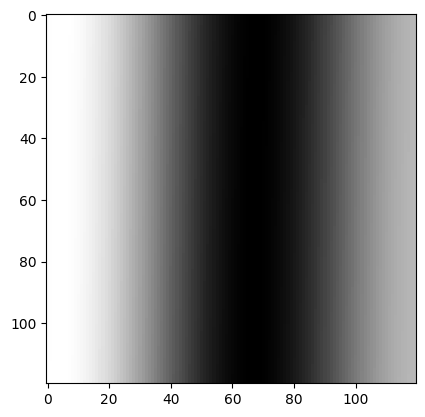

In [ ]:
t_approximation = reconstruct_y(x, torch.zeros_like(t_oi_flat), waves_params)
t_residual = t_oi_flat - t_approximation
t_approx_norm = normalize_torch(t_approximation.reshape(oi.squeeze().shape)).T
plt.imshow(t_approx_norm.cpu(), cmap='gray')

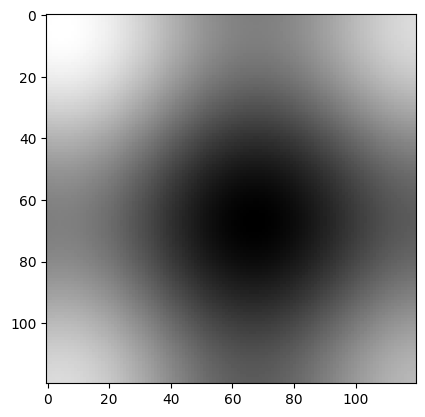

In [ ]:
approx_combo = (approx_norm + t_approx_norm) / 2
plt.imshow(approx_combo.cpu(), cmap='gray')

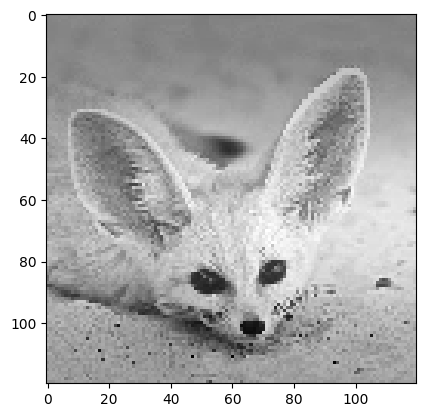

In [ ]:
plt.imshow(residual.reshape(oi.squeeze().shape).cpu(), cmap='gray')

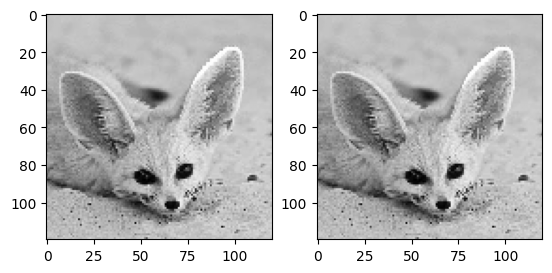

In [ ]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(residual.reshape(oi.squeeze().shape).cpu() + approximation.reshape(oi.squeeze().shape).cpu(), cmap='gray')
ax[1].imshow(oi.squeeze().cpu(), cmap='gray')

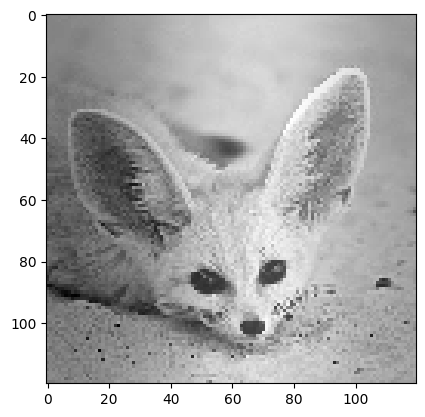

In [ ]:
plt.imshow(t_residual.reshape(oi.squeeze().shape).T.cpu(), cmap='gray')

In [ ]:
(oi.squeeze() - approx_combo).abs().mean()

tensor(0.2787, device='cuda:0')

In [ ]:
(oi.squeeze() - approx_norm).abs().mean()

tensor(0.3213, device='cuda:0')

In [ ]:
(oi.squeeze() - t_approx_norm).abs().mean()

tensor(0.3741, device='cuda:0')

In [ ]:
(oi.squeeze() - oi.squeeze().mean()).abs().mean()

tensor(0.1174, device='cuda:0')

: 

# End